# X-ray diseases classifier

This notebook demonstrates an image classification approach for analyzing chest X-ray images. The project uses the NIH Chest X-ray dataset and focuses on exploring a proof-of-concept method for detecting thoracic findings from medical imaging data.

Rabi Arbi, 2026

![banner](https://d1qpnt4t1p05jk.cloudfront.net/wp-content/uploads/2025/10/27082644/image-2544-1024x683.jpeg)

In [289]:
# Import core libraries and configure the notebook environment.
import collections, lightning, pandas as pd, platform, os, torch, torchvision, warnings

from torch.utils.data import Dataset, DataLoader
from lightning import LightningDataModule, LightningModule, Trainer
from torchvision import transforms
from torchmetrics.classification import MultilabelAccuracy, MultilabelPrecision, MultilabelRecall
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

import matplotlib.pyplot as plt

lightning.seed_everything(42)
torch.set_float32_matmul_precision("high")

data_path = "data"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

trainer_kwargs = {
    "accelerator": "gpu" if use_cuda else "cpu",
    "devices": 1,
}

if use_cuda:
    trainer_kwargs["precision"] = "16-mixed"

print(
    "Versions: python", platform.python_version(),
    "| torch", torch.__version__,
    "| torchvision", torchvision.__version__,
    "| lightning", lightning.__version__,
)
print("CUDA available:", use_cuda)
print("Active device:", device)
print("GPU:", torch.cuda.get_device_name(0) if use_cuda else "N/A")
print("Trainer kwargs:", trainer_kwargs)

Seed set to 42


Versions: python 3.14.0 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | lightning 2.6.1
CUDA available: True
Active device: cuda
GPU: NVIDIA GeForce RTX 5080
Trainer kwargs: {'accelerator': 'gpu', 'devices': 1, 'precision': '16-mixed'}


### explanation

- `collections` → counts labels and checks class balance  
- `lightning` → organizes training structure  
- `pandas` → reads and processes the dataset CSV  
- `platform` → shows Python/version info  
- `os` → handles file paths  
- `torch` → core deep learning library  
- `torchvision` → image utilities and transforms  
- `warnings` → controls warning messages  

- `Dataset` → builds a custom NIH dataset class  
- `DataLoader` → loads images in batches  

- `LightningDataModule` → manages data loading and splits  
- `LightningModule` → defines model, loss, and training steps  
- `Trainer` → runs training and validation  

- `transforms` → preprocesses X-ray images  
- `MultilabelAccuracy` → evaluates multi-label predictions  
- `MultilabelPrecision` → checks how many positive predictions are correct  
- `MultilabelRecall` → checks how many real positives are found  

- `CSVLogger` → saves training results  
- `EarlyStopping` → stops training when improvement stalls  
- `matplotlib.pyplot` → plots images and training curves  

- `seed_everything(42)` → makes runs reproducible  
- `set_float32_matmul_precision("high")` → improves GPU computation performance  
- `data_path = "data"` → sets dataset folder  
- `print(...)` → shows library versions

------------------------------------------------------------------------------------

# Loading Swin Transformer

In [290]:
# Load a pretrained Swin Transformer and replace the classification head for this dataset.
import torch.nn as nn
import torchvision

num_classes = 11

pretrained_model = torchvision.models.swin_t(weights="DEFAULT")
pretrained_model.head = nn.Linear(pretrained_model.head.in_features, num_classes)

criterion = nn.CrossEntropyLoss()

## What each part does:

- `swin_t(weights="DEFAULT")` → loads pretrained Swin Transformer
- `nn.Linear(...)` → replaces the classification head
- `num_classes` = 11 → one output per chest finding
- `CrossEntropyLoss()` → correct loss for single-label multi-class prediction

### Why the head was replaced

The original classification head was built for a different task.

This pretrained `Swin Transformer` came from ImageNet, so its head was made to predict **1000 ImageNet classes** such as dogs, cars, chairs, and other everyday objects.

This project is different:
- **input** = chest X-ray image  
- **output** = 11 thoracic findings  

So the original head does not match this target.

Inside the model:
- the early and middle layers learn general visual features  
- the head maps those features to the final class outputs  

That final mapping is task-specific.

The head was replaced because:
- the ImageNet output size is wrong  
- this project needs **11 outputs**  
- the new classes are completely different  
- this is how transfer learning adapts a pretrained model to a new task  

Simple example:

**Before**
- model sees an image  
- head predicts one of **1000 ImageNet classes**  

**After**
- model sees a chest X-ray  
- head predicts the 11 chest findings, such as **Atelectasis, Effusion, Mass, Pneumonia**, and others.

------------------------------------------------------------------------------------------------------

## Clean The Data


### No Finding Analysis

We will measure how many images are labeled **No Finding**. These samples may add less value for disease classification, so we review their proportion before deciding whether to keep or remove them.

In [291]:
# Load the NIH metadata CSV and measure how many rows are labeled No Finding.
from pathlib import Path

# Locate NIH metadata CSV from common project layouts.
candidate_csv_paths = [
    Path(data_path) / "Data_Entry_2017.csv",
    Path("Data_Entry_2017.csv"),
    Path("archive") / "Data_Entry_2017.csv",
]

csv_path = next((p for p in candidate_csv_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find Data_Entry_2017.csv. Checked: "
        + ", ".join(str(p) for p in candidate_csv_paths)
    )

df = pd.read_csv(csv_path)

if "Finding Labels" not in df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the metadata CSV.")

no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
no_finding_count = int(no_finding_mask.sum())
total_images = len(df)
other_findings_count = total_images - no_finding_count
no_finding_ratio = (no_finding_count / total_images) if total_images else 0.0

summary_table = pd.DataFrame(
    {
        "Metric": [
            "CSV used",
            "Total images",
            "Images with No Finding",
            "Images with Other Findings",
            "No Finding ratio",
        ],
        "Value": [
            str(csv_path),
            f"{total_images:,}",
            f"{no_finding_count:,}",
            f"{other_findings_count:,}",
            f"{no_finding_ratio:.2%}",
        ],
    }
)
display(summary_table)


,Metric,Value
0,CSV used,archive\Data_Entry_2017.csv
1,Total images,"112,120"
2,Images with No Finding,"60,361"
3,Images with Other Findings,"51,759"
4,No Finding ratio,53.84%


### Why It Can Be Better to Remove Some No Finding Images:
In this task, removing a portion of **No Finding** images can improve learning because the model then sees more disease-positive examples, reducing class imbalance and helping it focus on patterns related to thoracic abnormalities.

In [292]:
# Print the number of images after No Finding removal, if that step already ran.
# Prints only the number of images after removal (skip if removal not run yet).
if "total_after" in globals():
    print(total_after)
elif "df_clean" in globals():
    total_after = len(df_clean)
    print(total_after)
else:
    print("No Finding removal has not run yet. Skipping count.")

51759


In [293]:
# Remove all rows labeled No Finding from the metadata dataframe.
# Remove all rows labeled 'No Finding'. Skip if already removed.
if "df_clean" in globals() and "total_after" in globals():
    print("No Finding rows already removed. Skipping.")
else:
    if "df" not in globals():
        raise NameError("Run the metadata loading cell first to create df.")

    if "Finding Labels" not in df.columns:
        raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

    no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
    df_clean = df.loc[~no_finding_mask].copy()

    total_before = len(df)
    total_after = len(df_clean)
    removed_count = total_before - total_after

    print(f"Total images before: {total_before}")
    print(f"No Finding images removed: {removed_count}")
    print(f"Total images after removal: {total_after}")

    

No Finding rows already removed. Skipping.


Also some images in the dataset contain multiple disease labels, which can confuse the model because it is unclear which disease is the correct target. To improve model clarity and performance, these images will be removed. Only images with a single, clear disease label will be used, ensuring that each input corresponds to one specific prediction.


In [294]:
# Count how many metadata rows contain multiple disease labels.
# Count images that have more than one disease label (excluding 'No Finding').
if "Finding Labels" not in df_clean.columns:
    raise KeyError("Column 'Finding Labels' was not found in df_clean.")

label_count = (
    df_clean["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

multi_disease_count = int((label_count > 1).sum())
print(multi_disease_count)

20796


# Keep only one single-label image per patient and drop the rest.


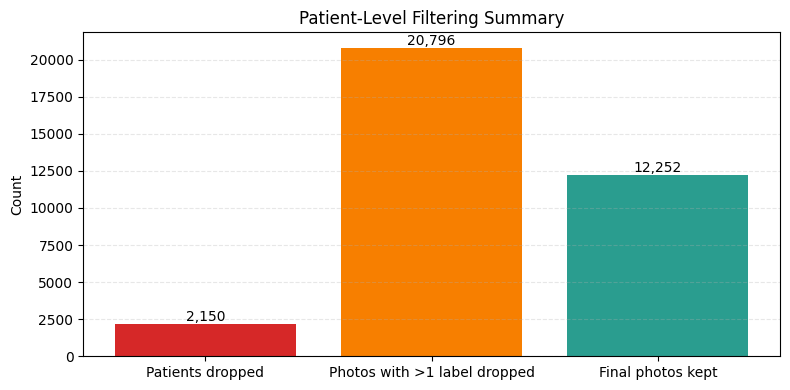

Patients dropped: 2150
Photos with >1 label dropped: 20796
Final photos kept (1 per patient): 12252


In [295]:
# Keep one single-label image per patient and drop the rest.
base_df = df_clean.copy() if "df_clean" in globals() else df.copy()

if "Finding Labels" not in base_df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in base_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column was not found in the dataframe.")

label_count_base = (
    base_df["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

single_label_df = base_df.loc[label_count_base == 1].copy()

if "Image Index" in single_label_df.columns:
    single_label_df = single_label_df.sort_values([patient_col, "Image Index"])
else:
    single_label_df = single_label_df.sort_values([patient_col])

df_one_image_per_patient = single_label_df.drop_duplicates(subset=patient_col, keep="first").copy()

patients_before = int(base_df[patient_col].nunique())
patients_after = int(df_one_image_per_patient[patient_col].nunique())
patients_dropped = patients_before - patients_after

multi_label_photos_dropped = int((label_count_base > 1).sum())
final_photos_kept = int(len(df_one_image_per_patient))

labels = ["Patients dropped", "Photos with >1 label dropped", "Final photos kept"]
values = [patients_dropped, multi_label_photos_dropped, final_photos_kept]
colors = ["#d62828", "#f77f00", "#2a9d8f"]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Patient-Level Filtering Summary")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Patients dropped: {patients_dropped}")
print(f"Photos with >1 label dropped: {multi_label_photos_dropped}")
print(f"Final photos kept (1 per patient): {final_photos_kept}")

# Chart: total images before any cleaning vs final images after all cleaning.


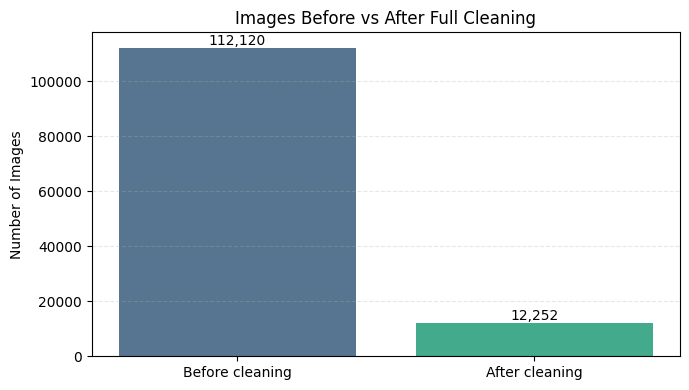

Before cleaning: 112120
After cleaning: 12252


In [296]:
# Plot the image count before cleaning versus after the full filtering pipeline.
before_cleaning = len(df) if "df" in globals() else total_images
after_cleaning = len(df_one_image_per_patient) if "df_one_image_per_patient" in globals() else final_photos_kept

labels = ["Before cleaning", "After cleaning"]
values = [before_cleaning, after_cleaning]
colors = ["#577590", "#43aa8b"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Images Before vs After Full Cleaning")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Before cleaning: {before_cleaning}")
print(f"After cleaning: {after_cleaning}")

# Randomly show 10 patients with one image ID and its label.


In [297]:
# Show a random sample of patients with their image IDs and labels.
sample_df = df_one_image_per_patient.copy()

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in sample_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column not found.")

image_col_candidates = ["Image Index", "ImageID", "image_id"]
image_col = next((c for c in image_col_candidates if c in sample_df.columns), None)
if image_col is None:
    raise KeyError("Image ID column not found.")

if "Finding Labels" not in sample_df.columns:
    raise KeyError("'Finding Labels' column not found.")

total_images_kept = len(sample_df)
n = min(10, total_images_kept)
random_10 = sample_df.sample(n=n).loc[:, [patient_col, image_col, "Finding Labels"]]
random_10 = random_10.reset_index(drop=True)

print(f"Total images after all filtering: {total_images_kept}")
print(f"Random sample of {n} patients (new each run):")
display(random_10)

Total images after all filtering: 12252
Random sample of 10 patients (new each run):


,Patient ID,Image Index,Finding Labels
0,22963,00022963_000.png,Infiltration
1,957,00000957_001.png,Atelectasis
2,7354,00007354_007.png,Infiltration
3,18190,00018190_000.png,Infiltration
4,18156,00018156_001.png,Atelectasis
5,22484,00022484_006.png,Consolidation
6,7166,00007166_001.png,Emphysema
7,11244,00011244_000.png,Atelectasis
8,3376,00003376_000.png,Effusion
9,2996,00002996_000.png,Pleural_Thickening


## Number of images Per class

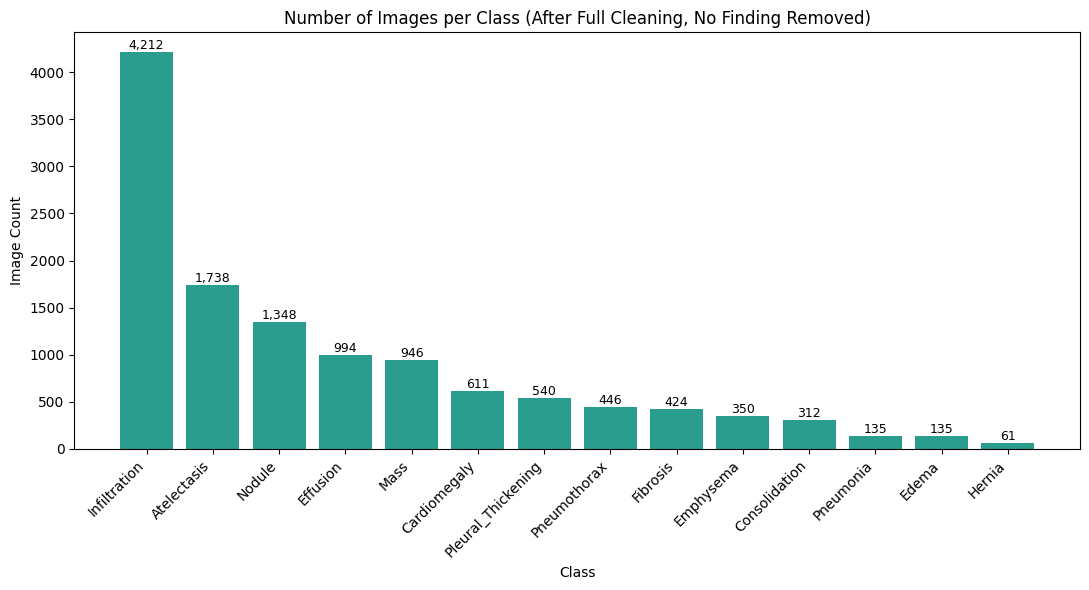

Total rows used for plotting: 12,252
Total disease labels plotted: 12,252
Total unique classes: 14


In [298]:
# Count and plot how many cleaned images remain in each disease class.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def build_clean_df(base_df: pd.DataFrame) -> pd.DataFrame:
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column was not found in the dataframe.")

    disease_df = base_df.loc[
        ~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")
    ].copy()
    label_count = disease_df["Finding Labels"].fillna("").astype(str).str.split("|").str.len()
    single_label_df = disease_df.loc[label_count == 1].copy()

    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in single_label_df.columns else [])
    return single_label_df.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first")

if "df_one_image_per_patient" in globals():
    plot_df = df_one_image_per_patient.copy()
else:
    if "df" in globals():
        base_df = df.copy()
    else:
        csv_candidates = [
            Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
            Path("Data_Entry_2017.csv"),
            Path("archive") / "Data_Entry_2017.csv",
        ]
        csv_path = next((p for p in csv_candidates if p.exists()), None)
        if csv_path is None:
            raise FileNotFoundError("Could not find Data_Entry_2017.csv")
        base_df = pd.read_csv(csv_path)

    if "Finding Labels" not in base_df.columns:
        raise KeyError("Column 'Finding Labels' not found in the dataframe.")
    plot_df = build_clean_df(base_df)

class_counts = (
    plot_df["Finding Labels"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne("") & s.str.casefold().ne("no finding")]
    .value_counts()
    .sort_values(ascending=False)
 )

if class_counts.empty:
    raise ValueError("No disease labels found after cleaning.")

plt.figure(figsize=(11, 6))
bars = plt.bar(class_counts.index, class_counts.values, color="#2a9d8f")
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}", ha="center", va="bottom", fontsize=9)

plt.title("Number of Images per Class (After Full Cleaning, No Finding Removed)")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Total rows used for plotting: {len(plot_df):,}")
print(f"Total disease labels plotted: {int(class_counts.sum()):,}")
print(f"Total unique classes: {class_counts.size}")

We observe that three disease classes (Pneumonia, Edema, and Hernia) each contain fewer than 150 images. This sample size is insufficient for effective model training and would likely result in poor generalization performance. Therefore, these underrepresented classes will be excluded from the dataset to maintain training data quality.

In [299]:
# Drop the rare classes that have too few examples for reliable training.
# Remove classes with insufficient data: Pneumonia, Edema, and Hernia
classes_to_drop = ["Pneumonia", "Edema", "Hernia"]

if "df_one_image_per_patient" in globals():
    df_filtered = df_one_image_per_patient.copy()
else:
    raise NameError("df_one_image_per_patient not found. Run the previous clustering cells first.")

if "Finding Labels" not in df_filtered.columns:
    raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

before_rows = len(df_filtered)
df_filtered = df_filtered[~df_filtered["Finding Labels"].isin(classes_to_drop)].copy()
after_rows = len(df_filtered)
dropped_rows = before_rows - after_rows

print(f"Classes removed: {', '.join(classes_to_drop)}")
print(f"Total images before removal: {before_rows}")
print(f"Total images after removal: {after_rows}")
print(f"Images dropped: {dropped_rows}")


Classes removed: Pneumonia, Edema, Hernia
Total images before removal: 12252
Total images after removal: 11921
Images dropped: 331


# Resize the images
 the images sizes are Too big (1024 * 1024) it will get too heavy to train the model the best solution is to resize it down to 384 * 384

In [300]:
# Resize original PNG images to 384x384 for faster training and lighter I/O.
from pathlib import Path
from PIL import Image

# Choose which image list to resize: filtered training set if available, otherwise all metadata rows.
resize_df = df_one_image_per_patient if "df_one_image_per_patient" in globals() else df

if "Image Index" not in resize_df.columns:
    raise KeyError("Column 'Image Index' not found in the dataframe.")

target_size = (384, 384)

# Support running notebook either from project root or from archive/ folder.
base_candidates = [Path("."), Path("archive")]
image_roots = []
for base in base_candidates:
    image_roots.extend(sorted(base.glob("images_*/images")))

if not image_roots:
    raise FileNotFoundError("Could not find any source folders matching images_*/images.")

output_base = Path("archive") if Path("archive").exists() else Path(".")
output_dir = output_base / "images_384"
output_dir.mkdir(parents=True, exist_ok=True)

# Build fast lookup for original image files across NIH folders.
image_lookup = {}
for root in image_roots:
    for p in root.glob("*.png"):
        image_lookup[p.name] = p

image_names = resize_df["Image Index"].dropna().astype(str).unique().tolist()

resized_count = 0
missing_count = 0
skipped_count = 0

for img_name in image_names:
    src = image_lookup.get(img_name)
    if src is None:
        missing_count += 1
        continue

    dst = output_dir / img_name
    if dst.exists():
        skipped_count += 1
        continue

    with Image.open(src) as im:
        im = im.convert("RGB")
        im = im.resize(target_size, Image.Resampling.LANCZOS)
        im.save(dst, format="PNG")
    resized_count += 1

print(f"Target size: {target_size}")
print(f"Source unique images: {len(image_names)}")
print(f"Resized now: {resized_count}")
print(f"Skipped (already resized): {skipped_count}")
print(f"Missing source files: {missing_count}")
print(f"Output folder: {output_dir}")

Target size: (384, 384)
Source unique images: 12252
Resized now: 0
Skipped (already resized): 12252
Missing source files: 0
Output folder: archive\images_384


# image inhancere

In [301]:
# Enhance resized X-ray images with CLAHE so subtle structures are easier to see.
import cv2
import numpy as np
from PIL import Image

def _to_uint8_grayscale(image_array: np.ndarray) -> np.ndarray:
    """Convert image to grayscale uint8 safely (handles float [0,1] and uint formats)."""
    arr = np.asarray(image_array)

    # Convert RGB/RGBA to grayscale first.
    if arr.ndim == 3:
        if arr.shape[2] == 4:
            arr = arr[:, :, :3]
        if arr.dtype != np.uint8:
            arr_min, arr_max = float(arr.min()), float(arr.max())
            if arr_max <= 1.0:
                arr = (arr * 255.0).clip(0, 255)
            else:
                arr = np.clip(arr, 0, 255)
            arr = arr.astype(np.uint8)
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    else:
        arr = arr.astype(np.float32)
        arr_min, arr_max = float(arr.min()), float(arr.max())
        if arr_max <= 1.0:
            arr = arr * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)

    return arr

def enhance_xray_image(image_array, method="clahe"):
    """Enhance X-ray image for better visibility."""
    gray = _to_uint8_grayscale(image_array)

    if method == "clahe":
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
    else:
        enhanced = cv2.equalizeHist(gray)

    return enhanced

print("Image enhancement function loaded (CLAHE and Histogram Equalization available)")

Image enhancement function loaded (CLAHE and Histogram Equalization available)


# Data Sampeling 

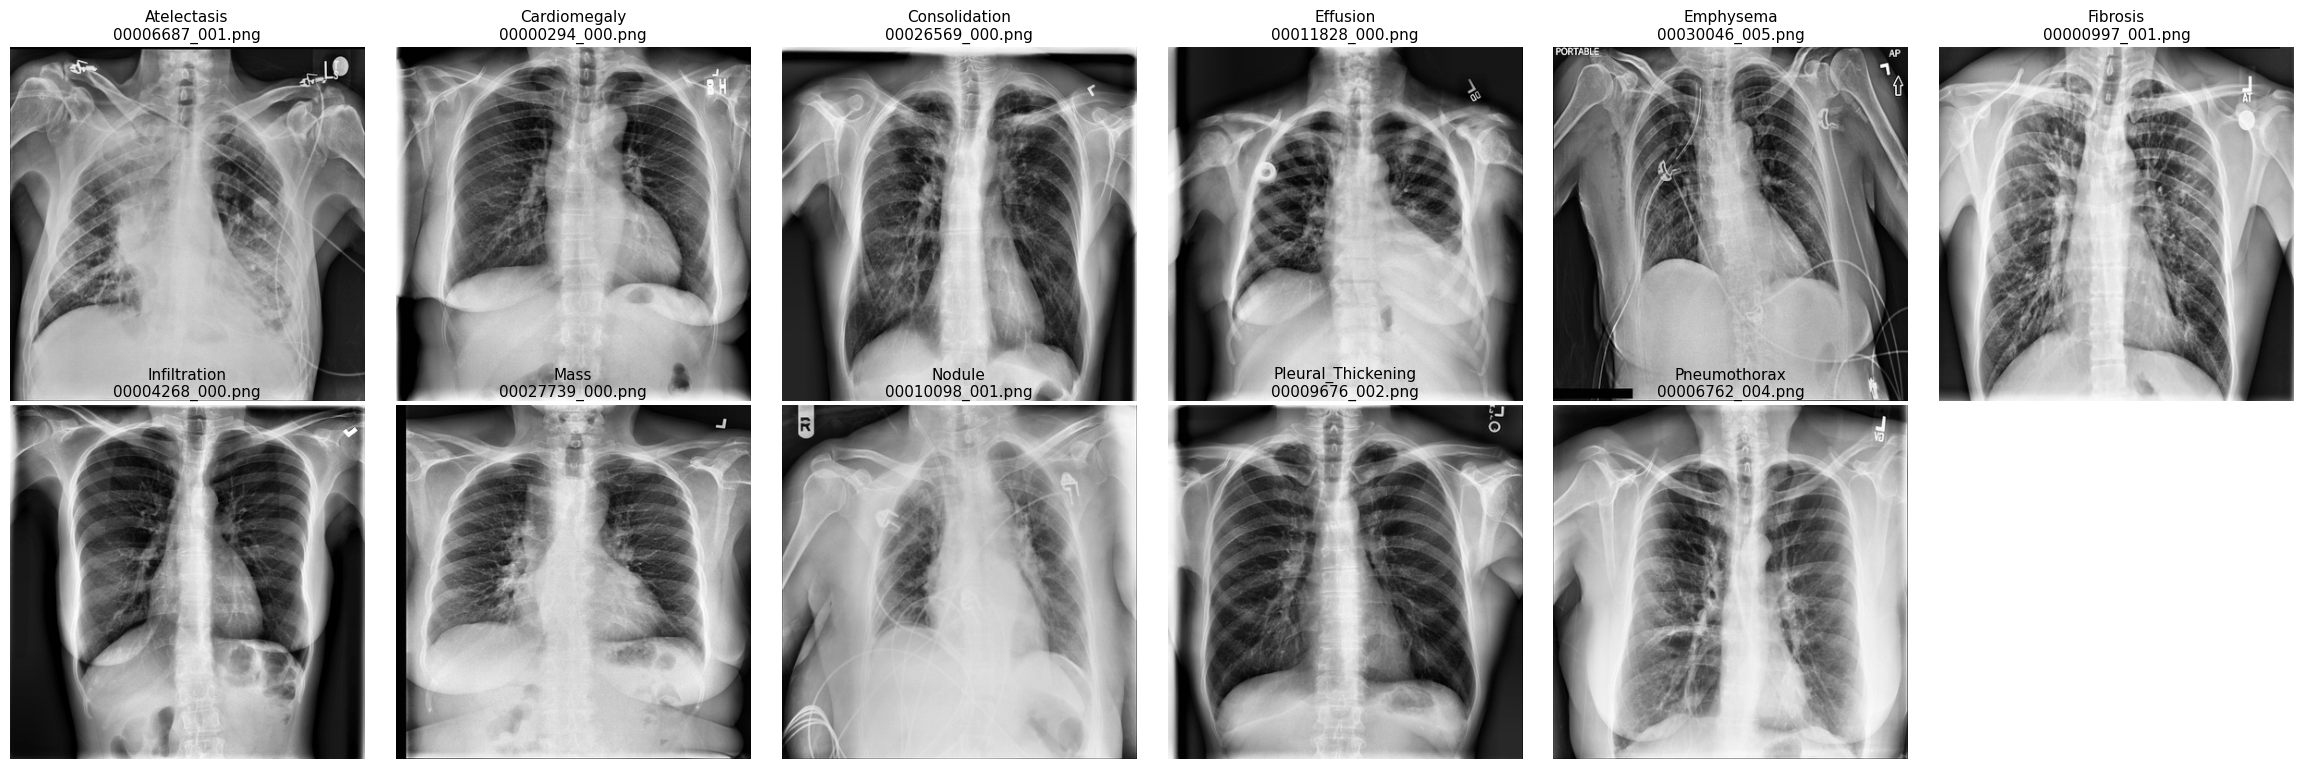

Displayed images: 11
Classes shown: Atelectasis, Cardiomegaly, Consolidation, Effusion, Emphysema, Fibrosis, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumothorax
✓ Bounding boxes are overlaid in red


In [302]:
# Random 11 images with their linked classes, with bounding boxes overlaid.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

if "df_filtered" in globals():
    sample_df = df_filtered.copy()
elif "df_one_image_per_patient" in globals():
    sample_df = df_one_image_per_patient.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Data_Entry_2017.csv not found.")

    base_df = pd.read_csv(csv_path)
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column not found.")

    work = base_df[~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")].copy()
    one_label = work[work["Finding Labels"].fillna("").astype(str).str.split("|").str.len().eq(1)].copy()
    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in one_label.columns else [])
    sample_df = one_label.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first").copy()

if "Finding Labels" not in sample_df.columns or "Image Index" not in sample_df.columns:
    raise KeyError("Required columns 'Finding Labels' and 'Image Index' were not found.")

selected = (
    sample_df[sample_df["Finding Labels"].fillna("").astype(str).str.strip().ne("")]
    .sample(frac=1)
    .drop_duplicates(subset="Finding Labels", keep="first")
    .sample(n=min(11, sample_df["Finding Labels"].nunique()))
    .sort_values("Finding Labels")
)

img_dir = next((d for d in [Path("archive") / "images_384", Path("images_384")] if d.exists()), None)
if img_dir is None:
    raise FileNotFoundError("images_384 folder not found. Run the resize cell first.")

selected = selected.copy()
selected["_img_path"] = selected["Image Index"].astype(str).apply(lambda x: img_dir / x)
selected = selected[selected["_img_path"].apply(lambda p: p.exists())].copy()
if selected.empty:
    raise FileNotFoundError("No sampled image files found in images_384.")

fig, axes = plt.subplots(2, 6, figsize=(24, 8), dpi=100)
axes = axes.ravel()
for i, ax in enumerate(axes):
    if i < len(selected):
        row = selected.iloc[i]
        img = plt.imread(row["_img_path"])
        enhanced_img = enhance_xray_image(img, method="clahe")
        ax.imshow(enhanced_img, cmap="gray")

        if "get_scaled_union_bbox" in globals():
            bbox = get_scaled_union_bbox(row["Image Index"], enhanced_img.shape[1], enhanced_img.shape[0])
            if bbox is not None:
                left, top, right, bottom = bbox
                rect = plt.Rectangle(
                    (left, top),
                    right - left,
                    bottom - top,
                    fill=False,
                    edgecolor="red",
                    linewidth=2,
                )
                ax.add_patch(rect)

        ax.set_title(f"{row['Finding Labels']}\n{row['Image Index']}", fontsize=11)
    ax.axis("off")

fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.04, wspace=0.03, hspace=0.01)
plt.show()

print(f"Displayed images: {len(selected)}")
print("Classes shown:", ", ".join(selected["Finding Labels"].tolist()))
if "get_scaled_union_bbox" in globals():
    print("✓ Bounding boxes are overlaid in red")
else:
    print("ℹ Run the Bounding box implementation cell to overlay boxes")

# Bounding box implementation

In [303]:
# Load bounding-box metadata and define helpers for cropping/drawing the lesion ROI.
from pathlib import Path
import pandas as pd

bbox_csv_candidates = [
    Path("archive") / "BBox_List_2017.csv",
    Path("BBox_List_2017.csv"),
]
bbox_csv_path = next((p for p in bbox_csv_candidates if p.exists()), None)
if bbox_csv_path is None:
    raise FileNotFoundError("BBox_List_2017.csv not found.")

bbox_df = pd.read_csv(bbox_csv_path)
if bbox_df.shape[1] < 6:
    raise ValueError("Bounding-box CSV must contain image index, label, x, y, w, h columns.")

bbox_df = bbox_df.iloc[:, :6].copy()
bbox_df.columns = ["Image Index", "Finding Label", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]
for col in ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]:
    bbox_df[col] = pd.to_numeric(bbox_df[col], errors="coerce")

bbox_df = bbox_df.dropna(subset=["Image Index", "bbox_x", "bbox_y", "bbox_w", "bbox_h"])

bbox_lookup = {}
for image_name, group in bbox_df.groupby("Image Index"):
    boxes = []
    for row in group.itertuples(index=False):
        left = float(row.bbox_x)
        top = float(row.bbox_y)
        right = left + float(row.bbox_w)
        bottom = top + float(row.bbox_h)
        if right > left and bottom > top:
            boxes.append((left, top, right, bottom))
    if boxes:
        bbox_lookup[image_name] = boxes

SOURCE_IMAGE_SIZE = 1024.0
print(f"Loaded bounding boxes for {len(bbox_lookup)} images from {bbox_csv_path}")

def get_union_bbox(image_name):
    boxes = bbox_lookup.get(image_name)
    if not boxes:
        return None
    left = min(box[0] for box in boxes)
    top = min(box[1] for box in boxes)
    right = max(box[2] for box in boxes)
    bottom = max(box[3] for box in boxes)
    return left, top, right, bottom


def get_scaled_union_bbox(image_name, image_width, image_height, padding=0.15):
    bbox = get_union_bbox(image_name)
    if bbox is None:
        return None

    left, top, right, bottom = bbox
    scale_x = image_width / SOURCE_IMAGE_SIZE
    scale_y = image_height / SOURCE_IMAGE_SIZE

    left *= scale_x
    right *= scale_x
    top *= scale_y
    bottom *= scale_y

    width = right - left
    height = bottom - top
    pad_x = width * padding
    pad_y = height * padding

    left = max(0, left - pad_x)
    top = max(0, top - pad_y)
    right = min(image_width, right + pad_x)
    bottom = min(image_height, bottom + pad_y)
    return left, top, right, bottom


def crop_image_to_bbox(image, image_name, padding=0.15):
    bbox = get_scaled_union_bbox(image_name, image.width, image.height, padding=padding)
    if bbox is None:
        return image

    left, top, right, bottom = bbox
    return image.crop((int(left), int(top), int(right), int(bottom)))

Loaded bounding boxes for 880 images from archive\BBox_List_2017.csv


## Data Splitting:

This step uses all available images from the retained 11 classes (no per-class downsampling).

A stratified split is applied to preserve class proportions across training (80%), validation (10%), and test (10%) sets for fair evaluation.

In [304]:
# Build stratified train/validation/test splits from bbox-annotated images only.
# Excludes the class "Mass".

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
exclude_classes = {"Mass"}

# Load the NIH metadata CSV from the project layout.
csv_candidates = [
    Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
    Path("Data_Entry_2017.csv"),
    Path("archive") / "Data_Entry_2017.csv",
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find Data_Entry_2017.csv")

base_df = pd.read_csv(csv_path)
required_metadata_cols = ["Finding Labels", "Image Index"]
missing_metadata_cols = [c for c in required_metadata_cols if c not in base_df.columns]
if missing_metadata_cols:
    raise KeyError(f"Missing required metadata columns: {missing_metadata_cols}")

# Keep only single-label disease images and remove No Finding.
base_df["Finding Labels"] = base_df["Finding Labels"].fillna("").astype(str).str.strip()
disease_df = base_df.loc[~base_df["Finding Labels"].str.casefold().eq("no finding")].copy()
label_count = disease_df["Finding Labels"].astype(str).str.split("|").str.len()
single_label_df = disease_df.loc[label_count == 1].copy()

# Remove excluded classes
single_label_df = single_label_df.loc[
    ~single_label_df["Finding Labels"].isin(exclude_classes)
].copy()

# Load bbox metadata and keep only classes/images that actually have bbox annotations.
bbox_csv_candidates = [
    Path("archive") / "BBox_List_2017.csv",
    Path("BBox_List_2017.csv"),
]
bbox_csv_path = next((p for p in bbox_csv_candidates if p.exists()), None)
if bbox_csv_path is None:
    raise FileNotFoundError("BBox_List_2017.csv not found.")

bbox_df = pd.read_csv(bbox_csv_path)
if bbox_df.shape[1] < 6:
    raise ValueError("Bounding-box CSV must contain image index, label, x, y, w, h columns.")

bbox_df = bbox_df.iloc[:, :6].copy()
bbox_df.columns = ["Image Index", "Finding Label", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]
bbox_df["Image Index"] = bbox_df["Image Index"].astype(str).str.strip()
bbox_df["Finding Label"] = bbox_df["Finding Label"].astype(str).str.strip()

# Normalize bbox labels to the NIH metadata names.
bbox_label_map = {
    "Infiltrate": "Infiltration",
}
bbox_df["Finding Label"] = bbox_df["Finding Label"].replace(bbox_label_map)

# Remove excluded classes from bbox annotations too
bbox_df = bbox_df.loc[~bbox_df["Finding Label"].isin(exclude_classes)].copy()

bbox_image_set = set(bbox_df["Image Index"].dropna().tolist())
bbox_class_set = set(bbox_df["Finding Label"].dropna().tolist())

split_source_df = single_label_df.loc[
    single_label_df["Image Index"].astype(str).isin(bbox_image_set)
    & single_label_df["Finding Labels"].astype(str).isin(bbox_class_set)
].copy()

# One row per image is enough because the bbox CSV only tells us which images are annotated.
split_source_df = split_source_df.drop_duplicates(subset="Image Index").reset_index(drop=True)

bbox_class_counts = split_source_df["Finding Labels"].value_counts().sort_index()
print(f"BBox-annotated images kept for training: {len(split_source_df)}")
print(f"BBox-annotated classes kept: {bbox_class_counts.size}")
print(f"Excluded classes: {', '.join(sorted(exclude_classes))}")
display(bbox_class_counts.rename("unique_images").to_frame())

if split_source_df.empty:
    raise ValueError("No bbox-annotated images matched the metadata after filtering.")

# Use the full bbox-backed set without per-class downsampling.
balanced_df = split_source_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nBBox-backed dataset distribution:")
print(balanced_df["Finding Labels"].value_counts().sort_index())
print(f"Total bbox-backed images: {len(balanced_df)}")


def train_val_test_split_safe(frame: pd.DataFrame, test_size: float, random_state: int):
    class_counts = frame["Finding Labels"].value_counts()
    stratify = frame["Finding Labels"] if len(class_counts) > 1 and class_counts.min() >= 2 else None
    if stratify is None and len(class_counts) > 1:
        print("⚠️ Falling back to a random split because at least one class has only one sample in this subset.")
    return train_test_split(
        frame,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify,
    )


# Perform train/val/test split on the bbox-backed data.
train_df, temp_df = train_val_test_split_safe(
    balanced_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

val_df, test_df = train_val_test_split_safe(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\n--- Split (80% train, 10% val, 10% test) ---")
print(f"Sample size used: {len(balanced_df)}")
print(f"Train size: {len(train_df)} ({len(train_df)/len(balanced_df):.2%})")
print(f"Val size:   {len(val_df)} ({len(val_df)/len(balanced_df):.2%})")
print(f"Test size:  {len(test_df)} ({len(test_df)/len(balanced_df):.2%})")

summary_df = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "pct": [
            len(train_df) / len(balanced_df),
            len(val_df) / len(balanced_df),
            len(test_df) / len(balanced_df),
        ],
    }
)
display(summary_df)

overall_dist = balanced_df["Finding Labels"].value_counts(normalize=True).sort_index()
train_dist = train_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
val_dist = val_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
test_dist = test_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)

dist_check = pd.DataFrame(
    {
        "overall": overall_dist,
        "train": train_dist,
        "val": val_dist,
        "test": test_dist,
    }
).round(4)

display(dist_check)

BBox-annotated images kept for training: 239
BBox-annotated classes kept: 7
Excluded classes: Mass


,unique_images
Finding Labels,
Atelectasis,55
Cardiomegaly,59
Effusion,25
Infiltration,19
Nodule,27
Pneumonia,20
Pneumothorax,34



BBox-backed dataset distribution:
Finding Labels
Atelectasis     55
Cardiomegaly    59
Effusion        25
Infiltration    19
Nodule          27
Pneumonia       20
Pneumothorax    34
Name: count, dtype: int64
Total bbox-backed images: 239

--- Split (80% train, 10% val, 10% test) ---
Sample size used: 239
Train size: 191 (79.92%)
Val size:   24 (10.04%)
Test size:  24 (10.04%)


,split,rows,pct
0,train,191,0.799163
1,val,24,0.100418
2,test,24,0.100418


,overall,train,val,test
Finding Labels,,,,
Atelectasis,0.2301,0.2304,0.2083,0.2500
Cardiomegaly,0.2469,0.2461,0.2500,0.2500
Effusion,0.1046,0.1047,0.1250,0.0833
Infiltration,0.0795,0.0785,0.0833,0.0833
Nodule,0.1130,0.1152,0.0833,0.1250
Pneumonia,0.0837,0.0838,0.0833,0.0833
Pneumothorax,0.1423,0.1414,0.1667,0.1250


--------------------------------

# Classifier 

In [305]:
# Create the image lookup, dataset class, and dataloaders used for training and evaluation.
from pathlib import Path
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision
from torchvision import transforms
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, TQDMProgressBar, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassAccuracy
import ssl

# Disable strict SSL checks because some pretrained weights may be downloaded from HTTPS sources.
ssl._create_default_https_context = ssl._create_unverified_context

# Make the run reproducible and keep PyTorch matrix math efficient on GPU.
L.seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# The split cell must run first so train/val/test tables exist.
if "train_df" not in globals() or "val_df" not in globals() or "test_df" not in globals():
    raise RuntimeError("train_df/val_df/test_df not found. Run the Data Splitting cell first.")

def discover_image_lookup() -> dict:
    # Collect every folder that may contain resized or original NIH images.
    roots = []
    candidates = [Path("archive") / "images_384", Path("images_384")]
    for p in candidates:
        if p.exists():
            roots.append(p)

    # Fallback to original NIH folders if resized folder is missing/incomplete.
    for base in [Path("."), Path("archive")]:
        roots.extend(sorted(base.glob("images_*/images")))

    # Build a filename -> path map so each CSV row can be linked to an image file quickly.
    lookup = {}
    for root in roots:
        for img_path in root.glob("*.png"):
            lookup.setdefault(img_path.name, img_path)
    return lookup

image_lookup = discover_image_lookup()
if not image_lookup:
    raise FileNotFoundError("No image files found in images_384 or images_*/images folders.")

label_col = "Finding Labels"
image_col = "Image Index"

# Confirm that the split tables contain the columns needed for training.
for col in [label_col, image_col]:
    if col not in train_df.columns:
        raise KeyError(f"Column '{col}' is missing from train_df.")

# Build a stable label-to-index mapping from the training split only.
all_labels = sorted(train_df[label_col].astype(str).str.strip().unique().tolist())
label_to_idx = {label: i for i, label in enumerate(all_labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
num_classes = len(all_labels)

print(f"Number of classes: {num_classes}")

# Work on copies so later steps do not mutate the original split tables in place.
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

# Attach a resolved image path to every row and drop rows whose files are missing.
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df[label_col] = split_df[label_col].astype(str).str.strip()
    split_df["_image_path"] = split_df[image_col].astype(str).map(image_lookup)
    before_rows = len(split_df)
    split_df.dropna(subset=["_image_path"], inplace=True)
    dropped = before_rows - len(split_df)
    if dropped > 0:
        print(f"{split_name}: dropped {dropped} rows because image file was missing.")

class XraySingleLabelDataset(Dataset):
    # Minimal PyTorch Dataset wrapper around the cleaned dataframe.
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        # Load the image from disk, crop to the lesion ROI when possible, and convert it to RGB.
        image = Image.open(row["_image_path"]).convert("RGB")
        if "crop_image_to_bbox" in globals():
            image = crop_image_to_bbox(image, row["Image Index"], padding=0.15)
        if self.transform is not None:
            image = self.transform(image)
        target = label_to_idx[row[label_col]]
        return image, target

# Training uses light augmentation so the model sees slightly varied versions of each image.
train_tfms = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation and test images must stay deterministic, so only resizing and normalization are applied.
val_test_tfms = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = XraySingleLabelDataset(train_df, transform=train_tfms)
val_ds = XraySingleLabelDataset(val_df, transform=val_test_tfms)
test_ds = XraySingleLabelDataset(test_df, transform=val_test_tfms)

batch_size = 16
num_workers = 0

# DataLoaders stream each split in batches for training, validation, and testing.
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Seed set to 42


Using device: cuda
Number of classes: 7
Train batches: 12 | Val batches: 2 | Test batches: 2


In [306]:
# Define the classifier, optimizer, and Lightning trainer with early stopping.
class XrayClassifier(L.LightningModule):
    # Swin Transformer classifier for single-label chest X-ray prediction.
    def __init__(self, n_classes: int, lr: float = 1e-4):
        super().__init__()
        self.save_hyperparameters()
        # Load the pretrained backbone and swap the ImageNet head for our target classes.
        self.backbone = torchvision.models.swin_t(weights="DEFAULT")
        in_features = self.backbone.head.in_features
        self.backbone.head = torch.nn.Linear(in_features, n_classes)
        self.criterion = torch.nn.CrossEntropyLoss()
        # Track accuracy separately for train and validation splits.
        self.train_acc = MulticlassAccuracy(num_classes=n_classes)
        self.val_acc = MulticlassAccuracy(num_classes=n_classes)

    def forward(self, x):
        # Forward pass through the Swin backbone.
        return self.backbone(x)

    def training_step(self, batch, batch_idx):
        # Compute training loss and update training accuracy.
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        # Evaluate validation loss and accuracy without updating model weights.
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.val_acc(logits, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        # Use Adam with weight decay for a small amount of regularization.
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)

# Instantiate the model with the current number of classes.
model = XrayClassifier(n_classes=num_classes, lr=1e-4)

# Save the best checkpoint and stop training once validation loss stops improving.
logger = CSVLogger(save_dir="archive", name="xray_training_logs")
checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    save_last=True,
    every_n_epochs=1,
    filename="best-{epoch:02d}-{val_loss:.4f}",
)
early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    min_delta=0.001,
    verbose=True,
)
progress_bar_cb = TQDMProgressBar(refresh_rate=10)
trainer_kwargs = globals().get("trainer_kwargs", {})

# Build the Lightning trainer using the active device settings from the setup cell.
trainer = L.Trainer(
    max_epochs=20,
    logger=logger,
    callbacks=[checkpoint_cb, early_stopping_cb, progress_bar_cb],
    enable_progress_bar=True,
    enable_checkpointing=True,
    log_every_n_steps=5,
    **trainer_kwargs,
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


# Training

In [307]:
# Fit the model on the training split and validate after each epoch.
if "trainer" not in globals() or "model" not in globals() or "train_loader" not in globals() or "val_loader" not in globals():
    raise RuntimeError("Trainer/model/dataloaders not found. Run the Classifier cell first.")

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader, ckpt_path=None)

print(f"Training complete. Logs: {trainer.logger.log_dir}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ SwinTransformer    │ 27.5 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 27.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 27.5 M                                                                                               
Total estimated model params size (MB): 110                                                                        
Modules in train mode: 183                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Epoch 3: 100%|██████████| 12/12 [00:02<00:00,  5.20it/s, v_num=28, val_loss=0.954, val_acc=0.724, train_loss=0.774, train_acc=0.617]

Metric val_loss improved by 0.041 >= min_delta = 0.001. New best score: 0.954


Epoch 6: 100%|██████████| 12/12 [00:02<00:00,  4.22it/s, v_num=28, val_loss=1.160, val_acc=0.590, train_loss=0.515, train_acc=0.760]

Monitored metric val_loss did not improve in the last 3 records. Best score: 0.954. Signaling Trainer to stop.


Epoch 6: 100%|██████████| 12/12 [00:02<00:00,  4.21it/s, v_num=28, val_loss=1.160, val_acc=0.590, train_loss=0.515, train_acc=0.760]
Training complete. Logs: archive\xray_training_logs\version_28


# validation chart 

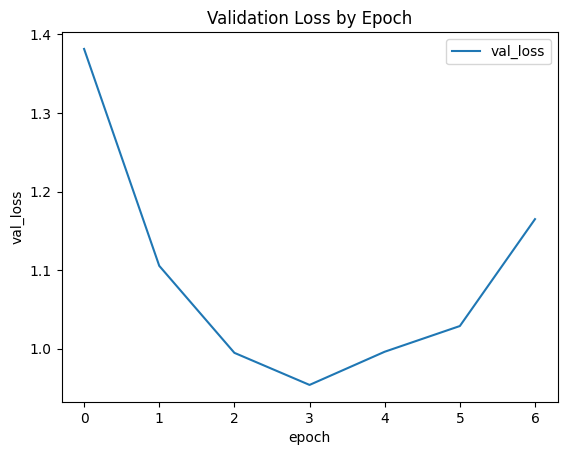

In [308]:
# Plot validation loss across epochs from the saved Lightning metrics.
import os
import pandas as pd

if "trainer" not in globals() or getattr(trainer, "logger", None) is None:
    raise RuntimeError("Trainer/logs not found. Run the Training cell first.")

metrics = pd.read_csv(os.path.join(trainer.logger.log_dir, "metrics.csv"))
loss_metrics = metrics[["epoch", "val_loss"]].dropna(subset=["val_loss"]).set_index("epoch")
plot = loss_metrics.plot(title="Validation Loss by Epoch", ylabel="val_loss")

# Overall Metrics

In [309]:
# Evaluate the trained model on the test split and print classification metrics.
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "model" not in globals() or "test_loader" not in globals():
    raise RuntimeError("Model or test_loader not found. Run the Training cell first.")

eval_device = next(model.parameters()).device
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(eval_device)
        targets = targets.to(eval_device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

correct = (all_preds == all_targets).sum()
total = len(all_targets)
test_accuracy = correct / total if total > 0 else 0.0

print(f"Test samples: {total}")
print(f"Correct predictions: {correct}")
print(f"Overall Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print("\n" + "=" * 80)
print("Per-Class Precision, Recall, and F1-Score:")
print("=" * 80)

if "idx_to_label" in globals():
    class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
else:
    class_names = [f"Class_{i}" for i in sorted(set(all_targets.tolist()) | set(all_preds.tolist()))]

print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))


Test samples: 24
Correct predictions: 17
Overall Accuracy: 0.7083 (70.83%)

Per-Class Precision, Recall, and F1-Score:
              precision    recall  f1-score   support

 Atelectasis     0.5000    0.5000    0.5000         6
Cardiomegaly     0.7500    1.0000    0.8571         6
    Effusion     0.5000    0.5000    0.5000         2
Infiltration     1.0000    1.0000    1.0000         2
      Nodule     1.0000    0.3333    0.5000         3
   Pneumonia     0.5000    0.5000    0.5000         2
Pneumothorax     1.0000    1.0000    1.0000         3

    accuracy                         0.7083        24
   macro avg     0.7500    0.6905    0.6939        24
weighted avg     0.7292    0.7083    0.6935        24



# confusion Metric

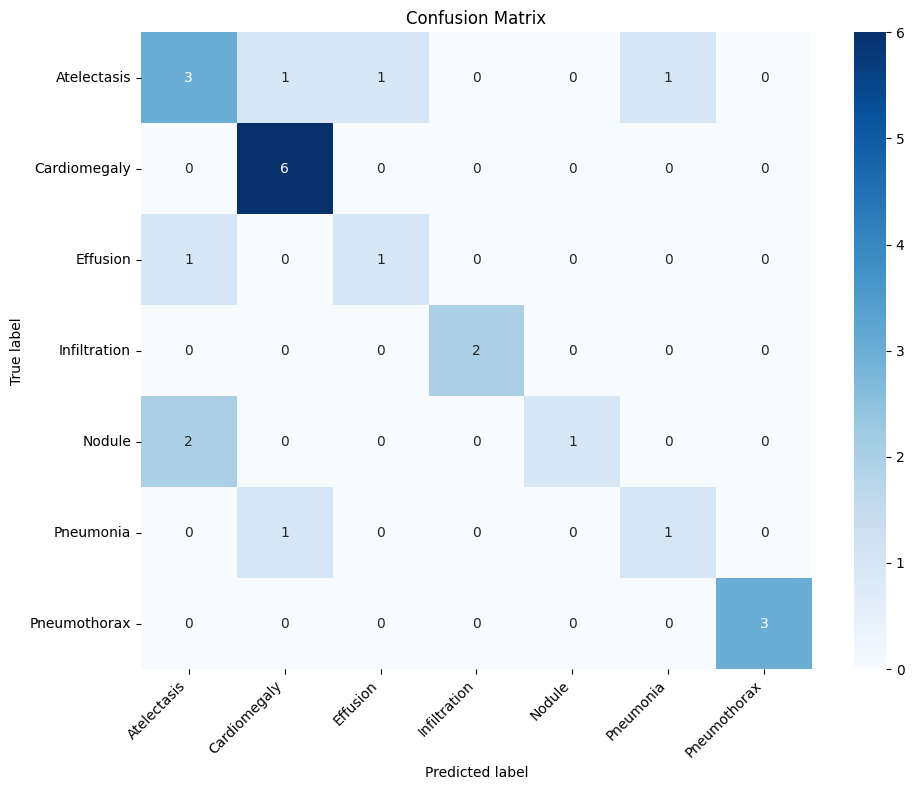


Most confused class pairs:


,True class,Predicted as,Count
0,Nodule,Atelectasis,2
1,Atelectasis,Cardiomegaly,1
2,Atelectasis,Effusion,1
3,Atelectasis,Pneumonia,1
4,Effusion,Atelectasis,1
5,Pneumonia,Cardiomegaly,1


In [310]:
# Plot the confusion matrix and list the strongest misclassifications.
# Build confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=list(range(len(class_names))))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analyze the strongest confusions (off-diagonal entries)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)

confusions = []
for true_idx in range(cm_off_diag.shape[0]):
    for pred_idx in range(cm_off_diag.shape[1]):
        count = int(cm_off_diag[true_idx, pred_idx])
        if count > 0:
            confusions.append(
                {
                    "True class": class_names[true_idx],
                    "Predicted as": class_names[pred_idx],
                    "Count": count,
                }
            )

if confusions:
    confusion_df = pd.DataFrame(confusions).sort_values("Count", ascending=False).reset_index(drop=True)
    print("\nMost confused class pairs:")
    display(confusion_df.head(10))
else:
    print("\nNo class confusions found on the test set.")